<a href="https://colab.research.google.com/github/aromaglob/X4/blob/main/projectx1socketrunx1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import os,time,datetime,threading,requests,numpy as np,websocket,yfinance as yf,asyncio,pandas as pd
from tensorflow import keras;from tensorflow.keras import layers;from sklearn.metrics import classification_report;from dotenv import load_dotenv
import nest_asyncio # Import nest_asyncio
nest_asyncio.apply() # Apply nest_asyncio to allow nested event loops

load_dotenv(dotenv_path="/content/projectx/.env")

class KBNasaSpacecraftTrader:
    def __init__(self,ticker_basket=["035720.KS","035420.KS","005930.KS"], fetch_interval=5, initial_cash=250000.0):
        self.ticker_basket=ticker_basket
        self.initial_capital = initial_cash # Store initial cash for return calculation
        self.current_available_cash=initial_cash # Use the passed initial_cash
        self.portfolio_ledger={}
        self.portfolio_ledger_lock = threading.Lock() # Add a lock for thread-safe access
        self.base_slippage_rate=0.0015
        self.commission_rate = 0.00015 # Add commission rate (e.g., 0.015%)
        self.models={}
        self.log_dir="/content/projectx/logs"
        os.makedirs(self.log_dir,exist_ok=True)
        self.current_live_prices={}
        self.current_volume_ratios={}
        self.current_live_features = {} # New: To store live calculated features (indicators)
        self.is_kill_switch_activated=False
        self.last_kill_switch_time=None
        self.tz_kst=datetime.timezone(datetime.timedelta(hours=9)) # [국내 배포 고정] 한국 표준시(KST) 타임존 정의
        self.stop_async_loop = asyncio.Event()
        self.fetch_interval = fetch_interval # Store the fetch interval

        # New attributes for tracking trading statistics
        self.total_bought_value = 0.0
        self.total_sold_value = 0.0
        self.total_bought_qty = 0
        self.total_sold_qty = 0
        self.total_buy_commission = 0.0
        self.total_sell_commission = 0.0
        self.total_buy_slippage = 0.0
        self.total_sell_slippage = 0.0
        self.bought_transactions = [] # To store individual buy transactions
        self.sold_transactions = []   # To store individual sell transactions

        self._prepare_yfinance_dataset_and_briefing()
        self._init_and_report_multi_deep_learning_cores()
        self.log_rotation_write("SYSTEM","[NASA 미션 컨트롤 등급의 결함 허용(Fault-Tolerance) 트레이딩 인프라 가동.")

    def log_rotation_write(self,level,message):
        now=datetime.datetime.now(self.tz_kst)
        today_date=now.strftime("%Y%m%d")
        timestamp=now.strftime("[%Y-%m-%d %H:%M:%S]")
        if not hasattr(self,'current_log_date_tracker') or today_date!=self.current_log_date_tracker:
            self.current_log_date_tracker=today_date
        log_file_name=f"trading_universe_{self.current_log_date_tracker}.txt"
        log_file_path=os.path.join(self.log_dir,log_file_name)
        full_log_line=f"{timestamp} [{level}] {message}\n"
        print(full_log_line.strip())
        try:
            with open(log_file_path,"a",encoding="utf-8") as f:f.write(full_log_line)
        except:pass

    def _prepare_yfinance_dataset_and_briefing(self):
        self.current_log_date_tracker=datetime.datetime.now(self.tz_kst).strftime("%Y%m%d")
        print("\n"+"="*70)
        print(f"[ProjectX 멀티 브리핑] 총 {len(self.ticker_basket)}개 감시 종목 바스켓 수송 분석 개시")
        print("="*70)

    def _init_and_report_multi_deep_learning_cores(self):
        for ticker in self.ticker_basket:
            print("\n"+"="*60)
            print(f"--- 🏋️‍♂️ [ProjectX] 종목 [{ticker}] 전용 맞춤형 AI 모델 학습 개시 ---")
            print("="*60)
            df=yf.download(ticker,period="2y",interval="1d");df['Open_Pct']=df['Open'].pct_change();df['High_Pct']=df['High'].pct_change();df['Low_Pct']=df['Low'].pct_change();df['Close_Pct']=df['Close'].pct_change();df['Volume_Pct']=df['Volume'].pct_change();df['Target']=(df['Close'].shift(-1)>df['Close']).astype(int);df=df.dropna()
            X=df[['Open_Pct','High_Pct','Low_Pct','Close_Pct','Volume_Pct']].values;y=df['Target'].values.reshape(-1,1);split_idx=int(len(X)*0.8);X_train,y_train,X_test,y_test=X[:split_idx],y[:split_idx],X[split_idx:],y[split_idx:]
            model=keras.Sequential([layers.Dense(64,activation="relu",input_shape=(5,)),layers.Dense(32,activation="relu"),layers.Dense(1,activation="sigmoid")]);model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
            model.fit(X_train,y_train,epochs=5,batch_size=16,validation_split=0.2,verbose=1);test_loss,test_acc=model.evaluate(X_test,y_test,verbose=1);print(f"📈 [{ticker}] 검증 정확도 (Accuracy) : {test_acc:.4f}")
            y_pred_prob=model.predict(X_test,verbose=0);y_pred=(y_pred_prob>=0.5).astype(int);print(classification_report(y_test,y_pred,target_names=["주가 하락(0)","주가 상승(1)"]));self.models[ticker]=model;print(f"🔒 [{ticker}] 전용 맞춤형 가중치 파라미터 세이브 완료.");print("="*60+"\n")

    def _calculate_transaction_costs(self, price, qty, side, live_volume_ratio):
        total_pure_value = price * qty
        commission_cost = total_pure_value * self.commission_rate

        active_slippage_rate = self.base_slippage_rate
        if live_volume_ratio >= 3.0:
            active_slippage_rate = 0.0035
        elif live_volume_ratio >= 2.5:
            active_slippage_rate = 0.0025

        slippage_cost = total_pure_value * active_slippage_rate

        actual_transaction_value = total_pure_value
        if side == "BUY":
            actual_transaction_value += commission_cost + slippage_cost
        elif side == "SELL":
            actual_transaction_value -= commission_cost + slippage_cost

        return commission_cost, slippage_cost, actual_transaction_value

    def _get_yfinance_live_price_and_volume_ratio(self,stock_code):
        try:
            ticker_data=yf.Ticker(stock_code);hist=ticker_data.history(period="5d");current_price=float(hist['Close'].iloc[-1]);yesterday_vol=float(hist['Volume'].iloc[-2]);today_vol=float(hist['Volume'].iloc[-1]);live_volume_ratio=today_vol/yesterday_vol if yesterday_vol>0 else 0.0
            self.current_live_prices[stock_code]=current_price;return current_price,live_volume_ratio
        except Exception as e:
            backup_price=self.current_live_prices.get(stock_code,0.0);print(f"📡 [NASA 이중화 가동] {stock_code} 채널 통신 단절 감지. 백업 텔레메트리 시세({backup_price:,.0f}원)로 자가 복구 우회 수송.");return backup_price,0.0

    def _get_yfinance_live_price(self,stock_code):
        price,_=self._get_yfinance_live_price_and_volume_ratio(stock_code);return price

    def send_order_packet(self, stock_code, qty, side="BUY", current_price=None, live_volume_ratio=0.0):
        # Fetch price and volume ratio if not provided
        if current_price is None or live_volume_ratio == 0.0:
            fetched_price, fetched_volume_ratio = self._get_yfinance_live_price_and_volume_ratio(stock_code)
            if fetched_price <= 0:
                self.log_rotation_write("ERROR", f"Failed to get live price for {stock_code}. Order cannot be placed.")
                return None
            if current_price is None: current_price = fetched_price
            if live_volume_ratio == 0.0: live_volume_ratio = fetched_volume_ratio

        commission_cost, slippage_cost, actual_transaction_value = self._calculate_transaction_costs(
            current_price, qty, side, live_volume_ratio
        )

        with self.portfolio_ledger_lock:
            if side == "BUY":
                self.current_available_cash -= actual_transaction_value
                self.total_bought_value += (current_price * qty)
                self.total_bought_qty += qty
                self.total_buy_commission += commission_cost
                self.total_buy_slippage += slippage_cost
                self.bought_transactions.append({
                    "code": stock_code,
                    "qty": qty,
                    "price": current_price,
                    "actual_cost": actual_transaction_value,
                    "commission": commission_cost,
                    "slippage": slippage_cost,
                    "timestamp": datetime.datetime.now(self.tz_kst).isoformat()
                })

                if stock_code in self.portfolio_ledger:
                    e_qty = self.portfolio_ledger[stock_code]["qty"]
                    e_price = self.portfolio_ledger[stock_code]["buy_price"]
                    n_qty = e_qty + qty
                    new_avg_pure_price = ((e_price * e_qty) + (current_price * qty)) / n_qty
                    self.portfolio_ledger[stock_code] = {"buy_price": new_avg_pure_price, "qty": n_qty}
                else:
                    self.portfolio_ledger[stock_code] = {"buy_price": current_price, "qty": qty}

                self.log_rotation_write("TRADE", f"✅ [매수 완료] {stock_code} {qty}주 (평단가: {current_price:,.0f}원). 총 비용: {actual_transaction_value:,.0f}원 (수수료: {commission_cost:,.0f}원, 슬리피지: {slippage_cost:,.0f}원). 잔액: {self.current_available_cash:,.0f}원")

            elif side == "SELL":
                if stock_code not in self.portfolio_ledger or self.portfolio_ledger[stock_code]["qty"] < qty:
                    self.log_rotation_write("WARNING", f"Attempted to sell {qty} of {stock_code} but only {self.portfolio_ledger.get(stock_code, {}).get('qty', 0)} held or not in ledger. Sale cancelled.")
                    return None

                self.current_available_cash += actual_transaction_value
                self.total_sold_value += (current_price * qty)
                self.total_sold_qty += qty
                self.total_sell_commission += commission_cost
                self.total_sell_slippage += slippage_cost
                self.sold_transactions.append({
                    "code": stock_code,
                    "qty": qty,
                    "price": current_price,
                    "actual_value": actual_transaction_value,
                    "commission": commission_cost,
                    "slippage": slippage_cost,
                    "timestamp": datetime.datetime.now(self.tz_kst).isoformat()
                })

                self.portfolio_ledger[stock_code]["qty"] -= qty
                if self.portfolio_ledger[stock_code]["qty"] <= 0:
                    del self.portfolio_ledger[stock_code]

                self.log_rotation_write("TRADE", f"💸 [매도 완료] {stock_code} {qty}주 (매도가: {current_price:,.0f}원). 총 정산: {actual_transaction_value:,.0f}원 (수수료: {commission_cost:,.0f}원, 슬리피지: {slippage_cost:,.0f}원). 잔액: {self.current_available_cash:,.0f}원")

        return {"status": "SUCCESS", "order_id": f"NASA_FLIGHT_ORDER_{stock_code}_{int(time.time())}",
                "commission_cost": commission_cost, "slippage_cost": slippage_cost,
                "actual_transaction_value": actual_transaction_value}

    def _display_trading_summary(self):
        print("\n" + "=" * 70)
        print("🚀 [시뮬레이션 거래 요약] 🚀")
        print("=" * 70)

        # Current Portfolio Value (unrealized)
        current_portfolio_value = 0.0
        for stock_code, asset_info in self.portfolio_ledger.items():
            current_price = self._get_yfinance_live_price(stock_code)
            if current_price > 0:
                current_portfolio_value += current_price * asset_info["qty"]

        total_assets = self.current_available_cash + current_portfolio_value
        total_return = total_assets - self.initial_capital
        total_return_rate = (total_return / self.initial_capital) * 100 if self.initial_capital > 0 else 0.0

        print(f"[초기 자본]: {self.initial_capital:,.0f}원")
        print(f"[현재 현금]: {self.current_available_cash:,.0f}원")
        print(f"[현재 보유 자산 가치]: {current_portfolio_value:,.0f}원")
        print(f"[총 자산 (현금+자산)]: {total_assets:,.0f}원")
        print(f"[총 수익/손실]: {total_return:,.0f}원")
        print(f"[총 수익률]: {total_return_rate:+.2f}%")
        print("-" * 70)

        print("[매수 통계]")
        print(f"  총 매수 금액 (순수 주가): {self.total_bought_value:,.0f}원")
        print(f"  총 매수 수량: {self.total_bought_qty}주")
        print(f"  총 매수 수수료: {self.total_buy_commission:,.0f}원")
        print(f"  총 매수 슬리피지: {self.total_buy_slippage:,.0f}원")
        print(f"  총 실제 매수 비용 (순수 + 수수료 + 슬리피지): {self.total_bought_value + self.total_buy_commission + self.total_buy_slippage:,.0f}원")
        print("-" * 70)

        print("[매도 통계]")
        print(f"  총 매도 금액 (순수 주가): {self.total_sold_value:,.0f}원")
        print(f"  총 매도 수량: {self.total_sold_qty}주")
        print(f"  총 매도 수수료: {self.total_sell_commission:,.0f}원")
        print(f"  총 매도 슬리피지: {self.total_sell_slippage:,.0f}원")
        print(f"  총 실제 매도 가치 (순수 - 수수료 - 슬리피지): {self.total_sold_value - self.total_sell_commission - self.total_sell_slippage:,.0f}원")
        print("=" * 70)

    def execute_take_profit_and_panic_sell_line(self):
        print("🔍 [잔고 감시 가동] 포트폴리오 자산의 실시간 수익률 및 리스크 체킹을 개시합니다.")
        for stock_code,asset_info in list(self.portfolio_ledger.items()):
            buy_price=asset_info["buy_price"];held_qty=asset_info["qty"];target_profit_price=buy_price*1.03;target_panic_sell_price=buy_price*0.95;current_price=self._get_yfinance_live_price(stock_code)
            if current_price<=0.0:continue
            current_return_pct=((current_price-buy_price)/buy_price)*100;print(f" [{stock_code}] 평단가: {buy_price:,.0f}원 | 현재가: {current_price:,.0f}원 | 수량: {held_qty}주 | 손익: {current_return_pct:+.2f}%")
            if current_price<=target_panic_sell_price:
                self.log_rotation_write("CRITICAL",f"🚨 [NASA 킬스위치 발동] {stock_code} 종목 -5% 패닉 가격 관측. 전 자산 일괄 즉시 강제 청산 프로토콜 수송.");self.is_kill_switch_activated=True;self.last_kill_switch_time=time.time()
                for t_code,t_info in list(self.portfolio_ledger.items()): # Iterate over a copy to allow modification
                    self.send_order_packet(t_code,t_info["qty"],side="SELL") # send_order_packet now handles ledger removal
                break
            if current_price>=target_profit_price:
                self.log_rotation_write("STRATEGY", f"🌟 [익절 타깃 도달] {stock_code} 종목 실시간 +3% 상방 터치 성공. 수익 실현!");order_res=self.send_order_packet(stock_code,held_qty,side="SELL")
                if order_res and order_res["status"] == "SUCCESS":
                    self.log_rotation_write("TRADE", f"💰 [익절 완료] 종목코드 {stock_code} {held_qty}주 마진 청산 성공.")

    def run_trading_orchestration_cycle(self):
        self.log_rotation_write("SYSTEM","⏰ 장중 실시간 AI 추론 및 실전 계좌 감시 루프 개시")
        if self.is_kill_switch_activated:
            if time.time()-self.last_kill_switch_time<86400:self.log_rotation_write("SECURITY","🚨 [NASA 안전 가동] 시스템이 현재 긴급 동결 모드 상태입니다. 신규 매수 수송을 영구 차단합니다.");return
            else:self.is_kill_switch_activated=False
        self.execute_take_profit_and_panic_sell_line();active_snapshot_pool=[]
        for ticker in self.ticker_basket:
            current_market_price,live_volume_ratio=self._get_yfinance_live_price_and_volume_ratio(ticker)
            if current_market_price>0:active_snapshot_pool.append({"ticker":ticker,"price":current_market_price,"volume_ratio":live_volume_ratio})
        active_snapshot_pool=sorted(active_snapshot_pool,key=lambda x:x["volume_ratio"],reverse=True)
        for stock_data in active_snapshot_pool:
            ticker=stock_data["ticker"];current_market_price=stock_data["price"];live_volume_ratio=stock_data["volume_ratio"];active_slippage_rate=0.0035 if live_volume_ratio>=3.0 else self.base_slippage_rate;buy_threshold=0.50 if live_volume_ratio>=3.0 else (0.55 if live_volume_ratio>=2.5 else 0.65);status_msg=f"🔥 [스나이퍼 락온: {live_volume_ratio:.2f}배 대장주] 슬리피지 예비비 0.35% 및 장벽 50% 완화!" if live_volume_ratio>=3.0 else (f"🚀 [수급 급증 상태: {live_volume_ratio:.2f}배] 장벽 55% 하향 조정." if live_volume_ratio>=2.5 else f"⏱ [일반 수급 상태: {live_volume_ratio:.2f}배] 보수적 기준선 65% 고수.")
            if self.current_available_cash<current_market_price:print(f"❌ [자산 방어벽] 예수금 부족으로 [{ticker}] 진입 차단.");continue
            features=np.array([[0.01,0.02,-0.01,0.005,0.1]],dtype=np.float32);current_stock_model=self.models.get(ticker)
            if current_stock_model is None:continue
            prob=float(current_stock_model(features,training=False).numpy());target_entry_qty=3 if prob>=0.80 else 1;weight_msg=f"💪 [강력 확신: AI {prob*100:.1f}%] 1회 진입 수량 3주 가중 증액 수송!" if prob>=0.80 else f"⏱ [일반 추론: AI {prob*100:.1f}%] 표준 1주 분할 진입 가동.";

            # Calculate estimated costs for display purposes before actual order placement
            _, _, estimated_total_cost = self._calculate_transaction_costs(
                current_market_price, target_entry_qty, "BUY", live_volume_ratio
            )
            print(f"🔍 [{ticker}] {status_msg}");print(f"🔍 [{ticker}] {weight_msg}");print(f"🛡️ [{ticker}] 요구 자금: {estimated_total_cost:,.0f}원 (보유 예수금: {self.current_available_cash:,.0f}원)")

            if self.current_available_cash < estimated_total_cost: # Use estimated_total_cost for cash check
                print(f"❌ [자산 방어벽] 자금 부족으로 [{ticker}] 진입 차단.");print("-"*50);continue
            print(f"🔮 [AI 판정 지표] 최종 분석 결과: {prob*100:.2f}% (요구 목표치: {buy_threshold*100:.0f}%)")
            if prob>=buy_threshold:
                self.log_rotation_write("STRATEGY", f"🛒 [가변 수산 필터 통과] 최선순위 주도주 {ticker} {target_entry_qty}주 매수 주문 전송.")
                order_res = self.send_order_packet(ticker, target_entry_qty, side="BUY",
                                                    current_price=current_market_price,
                                                    live_volume_ratio=live_volume_ratio)
                if order_res and order_res["status"] == "SUCCESS":
                    # All cash, ledger, and tracking updates are now handled within send_order_packet
                    pass
                else:
                    self.log_rotation_write("ERROR", f"❌ [{ticker}] 매수 주문 실패. 사유: {order_res if order_res else '알 수 없음'}")

            else:print(f"⏱ [{ticker}] 분석 신뢰도 {prob*100:.1f}% -> 목표 조건({buy_threshold*100:.0f}%) 미달로 관망.");print("-"*50)
        self._display_trading_summary() # Call the summary method at the end of each cycle

if __name__ == "__main__":
    import pandas as pd
    my_advanced_basket=["035720.KS","035420.KS","005930.KS"];real_trading_engine=KBNasaSpacecraftTrader(ticker_basket=my_advanced_basket)
    for i in range(2):
        real_trading_engine.run_trading_orchestration_cycle()
        if i<1:time.sleep(2)



[ProjectX 멀티 브리핑] 총 3개 감시 종목 바스켓 수송 분석 개시

--- 🏋️‍♂️ [ProjectX] 종목 [035720.KS] 전용 맞춤형 AI 모델 학습 개시 ---


/tmp/ipykernel_1390/3358264834.py:70: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker,period="2y",interval="1d");df['Open_Pct']=df['Open'].pct_change();df['High_Pct']=df['High'].pct_change();df['Low_Pct']=df['Low'].pct_change();df['Close_Pct']=df['Close'].pct_change();df['Volume_Pct']=df['Volume'].pct_change();df['Target']=(df['Close'].shift(-1)>df['Close']).astype(int);df=df.dropna()
[*********************100%***********************]  1 of 1 completed

Epoch 1/5



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4838 - loss: 0.6980 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5325 - loss: 0.6909 - val_accuracy: 0.5128 - val_loss: 0.6937
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5357 - loss: 0.6903 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5260 - loss: 0.6886 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5292 - loss: 0.6880 - val_accuracy: 0.5000 - val_loss: 0.6928
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5773 - loss: 0.6806 
📈 [035720.KS] 검증 정확도 (Accuracy) : 0.5773
              precision    recall  f1-score   support

    주가 하락(0)       0.58      0.98      0.73        56
    주가 상승(1)       0.50      0.02      0.05        41

    accuracy                           0.58        97
   macro avg       0.54      0.50      0.39        97

...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5065 - loss: 0.6959 - val_accuracy: 0.4231 - val_loss: 0.6968
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5065 - loss: 0.6942 - val_accuracy: 0.4359 - val_loss: 0.6935
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5065 - loss: 0.6928 - val_accuracy: 0.4231 - val_loss: 0.6941
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5065 - loss: 0.6928 - val_accuracy: 0.4231 - val_loss: 0.6951
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5065 - loss: 0.6920 - val_accuracy: 0.4487 - val_loss: 0.6950
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4433 - loss: 6.4913 
📈 [005930.KS] 검증 정확도 (Accuracy) : 0.4433
              precision    recall  f1-score   support

    주가 하락(0)       0.45      0.98      0.61        44
    주가 상승(1)       0.00      0.00      0.00        53

    accuracy                           0.44        97
   macro avg       0.22      0.49      0.31        97

/tmp/ipykernel_1390/3358264834.py:249: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob=float(current_stock_model(features,training=False).numpy());target_entry_qty=3 if prob>=0.80 else 1;weight_msg=f"💪 [강력 확신: AI {prob*100:.1f}%] 1회 진입 수량 3주 가중 증액 수송!" if prob>=0.80 else f"⏱ [일반 추론: AI {prob*100:.1f}%] 표준 1주 분할 진입 가동.";


🔍 [035420.KS] ⏱ [일반 수급 상태: 0.64배] 보수적 기준선 65% 고수.
🔍 [035420.KS] ⏱ [일반 추론: AI 49.9%] 표준 1주 분할 진입 가동.
🛡️ [035420.KS] 요구 자금: 214,353원 (보유 예수금: 250,000원)
🔮 [AI 판정 지표] 최종 분석 결과: 49.87% (요구 목표치: 65%)
⏱ [035420.KS] 분석 신뢰도 49.9% -> 목표 조건(65%) 미달로 관망.
--------------------------------------------------
❌ [자산 방어벽] 예수금 부족으로 [005930.KS] 진입 차단.
🔍 [035720.KS] ⏱ [일반 수급 상태: 0.15배] 보수적 기준선 65% 고수.
🔍 [035720.KS] ⏱ [일반 추론: AI 47.9%] 표준 1주 분할 진입 가동.
🛡️ [035720.KS] 요구 자금: 36,310원 (보유 예수금: 250,000원)
🔮 [AI 판정 지표] 최종 분석 결과: 47.85% (요구 목표치: 65%)
⏱ [035720.KS] 분석 신뢰도 47.9% -> 목표 조건(65%) 미달로 관망.
--------------------------------------------------

🚀 [시뮬레이션 거래 요약] 🚀
[초기 자본]: 250,000원
[현재 현금]: 250,000원
[현재 보유 자산 가치]: 0원
[총 자산 (현금+자산)]: 250,000원
[총 수익/손실]: 0원
[총 수익률]: +0.00%
----------------------------------------------------------------------
[매수 통계]
  총 매수 금액 (순수 주가): 0원
  총 매수 수량: 0주
  총 매수 수수료: 0원
  총 매수 슬리피지: 0원
  총 실제 매수 비용 (순수 + 수수료 + 슬리피지): 0원
-----------------------------------------------------------------

/tmp/ipykernel_1390/3358264834.py:249: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob=float(current_stock_model(features,training=False).numpy());target_entry_qty=3 if prob>=0.80 else 1;weight_msg=f"💪 [강력 확신: AI {prob*100:.1f}%] 1회 진입 수량 3주 가중 증액 수송!" if prob>=0.80 else f"⏱ [일반 추론: AI {prob*100:.1f}%] 표준 1주 분할 진입 가동.";


In [ ]:
import os,time,datetime,threading,requests,numpy as np,websocket,yfinance as yf
from tensorflow import keras;from tensorflow.keras import layers;from sklearn.metrics import classification_report;from dotenv import load_dotenv
load_dotenv(dotenv_path="/content/projectx/.env")
class KBNasaSpacecraftTrader:
    def __init__(self,ticker_basket=["035720.KS","035420.KS","005930.KS"]):
        self.ticker_basket=ticker_basket;self.current_available_cash=250000.0;self.portfolio_ledger={};self.base_slippage_rate=0.0015;self.models={};self.log_dir="/content/projectx/logs";os.makedirs(self.log_dir,exist_ok=True)
        self.current_live_prices={};self.is_kill_switch_activated=False;self.last_kill_switch_time=None;self.tz_kst=datetime.timezone(datetime.timedelta(hours=9)) # 🔒 [국내 배포 고정] 한국 표준시(KST) 타임존 정의
        self._prepare_yfinance_dataset_and_briefing();self._init_and_report_multi_deep_learning_cores();self.log_rotation_write("SYSTEM","🚀 NASA 미션 컨트롤 등급의 결함 허용(Fault-Tolerance) 트레이딩 인프라 가동.")
    def log_rotation_write(self,level,message):
        now=datetime.datetime.now(self.tz_kst);today_date=now.strftime("%Y%m%d");timestamp=now.strftime("[%Y-%m-%d %H:%M:%S]")
        if not hasattr(self,'current_log_date_tracker') or today_date!=self.current_log_date_tracker:self.current_log_date_tracker=today_date
        log_file_name=f"trading_universe_{self.current_log_date_tracker}.txt";log_file_path=os.path.join(self.log_dir,log_file_name);full_log_line=f"{timestamp} [{level}] {message}\n";print(full_log_line.strip())
        try:
            with open(log_file_path,"a",encoding="utf-8") as f:f.write(full_log_line)
        except:pass
    def _prepare_yfinance_dataset_and_briefing(self):
        self.current_log_date_tracker=datetime.datetime.now(self.tz_kst).strftime("%Y%m%d");print("\n"+"="*70);print(f"📡 [ProjectX 멀티 브리핑] 총 {len(self.ticker_basket)}개 감시 종목 바스켓 수송 분석 개시");print("="*70)
        for ticker in self.ticker_basket:
            try:
                ticker_df=yf.download(ticker,period="5d",interval="1d");recent_2days=ticker_df[['Open','High','Low','Close','Volume']].tail(4);print(f"\n▶ 종목코드: {ticker}");pd.set_option('display.float_format',lambda x:'{:,.2f}'.format(x));print(recent_2days)
                yesterday_close=float(recent_2days['Close'].iloc[0]);today_close=float(recent_2days['Close'].iloc[1]);yesterday_volume=float(recent_2days['Volume'].iloc[0]);today_volume=float(recent_2days['Volume'].iloc[1])
                price_change=today_close-yesterday_close;price_change_pct=(price_change/yesterday_close)*100;change_sign=f"▲ +{price_change:,.2f}" if price_change>0 else (f"▼ {price_change:,.2f}" if price_change<0 else "■ 0.00");volume_ratio=today_volume/yesterday_volume if yesterday_volume>0 else 0.0
                print(f"  전일비 변동폭: {change_sign}원 ({price_change_pct:+.2f}%)");print(f"  📊 실시간 거래량 폭발 비율 (Volume Ratio): {volume_ratio:.2f}배 (전일 대비 {volume_ratio*100:.1f}%)");print("-"*50)
            except Exception as e:print(f"⚠️ [{ticker}] 실시간 파싱 실패: {e}")
        print("="*70+"\n")
    def _init_and_report_multi_deep_learning_cores(self):
        for ticker in self.ticker_basket:
            print("\n"+"="*60);print(f"--- 🏋️‍♂️ [ProjectX] 종목 [{ticker}] 전용 맞춤형 AI 모델 학습 개시 ---");print("="*60)
            df=yf.download(ticker,period="2y",interval="1d");df['Open_Pct']=df['Open'].pct_change();df['High_Pct']=df['High'].pct_change();df['Low_Pct']=df['Low'].pct_change();df['Close_Pct']=df['Close'].pct_change();df['Volume_Pct']=df['Volume'].pct_change();df['Target']=(df['Close'].shift(-1)>df['Close']).astype(int);df=df.dropna()
            X=df[['Open_Pct','High_Pct','Low_Pct','Close_Pct','Volume_Pct']].values;y=df['Target'].values.reshape(-1,1);split_idx=int(len(X)*0.8);X_train,y_train,X_test,y_test=X[:split_idx],y[:split_idx],X[split_idx:],y[split_idx:]
            model=keras.Sequential([layers.Dense(64,activation="relu",input_shape=(5,)),layers.Dense(32,activation="relu"),layers.Dense(1,activation="sigmoid")]);model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
            model.fit(X_train,y_train,epochs=5,batch_size=16,validation_split=0.2,verbose=1);test_loss,test_acc=model.evaluate(X_test,y_test,verbose=1);print(f"📈 [{ticker}] 검증 정확도 (Accuracy) : {test_acc:.4f}")
            y_pred_prob=model.predict(X_test,verbose=0);y_pred=(y_pred_prob>=0.5).astype(int);print(classification_report(y_test,y_pred,target_names=["주가 하락(0)","주가 상승(1)"]));self.models[ticker]=model;print(f"🔒 [{ticker}] 전용 맞춤형 가중치 파라미터 세이브 완료.");print("="*60+"\n")
    def execute_take_profit_and_panic_sell_line(self):
        print("🔍 [잔고 감시 가동] 포트폴리오 자산의 실시간 수익률 및 리스크 체킹을 개시합니다.")
        for stock_code,asset_info in list(self.portfolio_ledger.items()):
            buy_price=asset_info["buy_price"];held_qty=asset_info["qty"];target_profit_price=buy_price*1.03;target_panic_sell_price=buy_price*0.95;current_price=self._get_yfinance_live_price(stock_code)
            if current_price<=0.0:continue
            current_return_pct=((current_price-buy_price)/buy_price)*100;print(f" [{stock_code}] 평단가: {buy_price:,.0f}원 | 현재가: {current_price:,.0f}원 | 수량: {held_qty}주 | 손익: {current_return_pct:+.2f}%")
            if current_price<=target_panic_sell_price:
                self.log_rotation_write("CRITICAL",f"🚨 [NASA 킬스위치 발동] {stock_code} 종목 -5% 패닉 가격 관측. 전 자산 일괄 즉시 강제 청산 프로토콜 수송.");self.is_kill_switch_activated=True;self.last_kill_switch_time=time.time()
                for t_code,t_info in list(self.portfolio_ledger.items()):self.send_order_packet(t_code,t_info["qty"],side="SELL");del self.portfolio_ledger[t_code]
                break
            if current_price>=target_profit_price:
                self.log_rotation_write("STRATEGY", f"🌟 [익절 타깃 도달] {stock_code} 종목 실시간 +3% 상방 터치 성공. 수익 실현!");order_res=self.send_order_packet(stock_code,held_qty,side="SELL")
                if order_res:self.log_rotation_write("TRADE", f"💰 [익절 완료] 종목코드 {stock_code} {held_qty}주 마진 청산 성공.");del self.portfolio_ledger[stock_code]
    def _get_yfinance_live_price_and_volume_ratio(self,stock_code):
        try:
            ticker_data=yf.Ticker(stock_code);hist=ticker_data.history(period="5d");current_price=float(hist['Close'].iloc[-1]);yesterday_vol=float(hist['Volume'].iloc[-2]);today_vol=float(hist['Volume'].iloc[-1]);live_volume_ratio=today_vol/yesterday_vol if yesterday_vol>0 else 0.0
            self.current_live_prices[stock_code]=current_price;return current_price,live_volume_ratio
        except Exception as e:
            backup_price=self.current_live_prices.get(stock_code,0.0);print(f"📡 [NASA 이중화 가동] {stock_code} 채널 통신 단절 감지. 백업 텔레메트리 시세({backup_price:,.0f}원)로 자가 복구 우회 수송.");return backup_price,0.0
    def _get_yfinance_live_price(self,stock_code):
        price,_=self._get_yfinance_live_price_and_volume_ratio(stock_code);return price
    def send_order_packet(self,stock_code,qty,side="BUY"):
        return {"status":"SUCCESS","order_id":"NASA_FLIGHT_ORDER_A"}
    def run_trading_orchestration_cycle(self):
        self.log_rotation_write("SYSTEM","⏰ 장중 실시간 AI 추론 및 실전 계좌 감시 루프 개시")
        if self.is_kill_switch_activated:
            if time.time()-self.last_kill_switch_time<86400:self.log_rotation_write("SECURITY","🚨 [NASA 안전 가동] 시스템이 현재 긴급 동결 모드 상태입니다. 신규 매수 수송을 영구 차단합니다.");return
            else:self.is_kill_switch_activated=False
        self.execute_take_profit_and_panic_sell_line();active_snapshot_pool=[]
        for ticker in self.ticker_basket:
            current_market_price,live_volume_ratio=self._get_yfinance_live_price_and_volume_ratio(ticker)
            if current_market_price>0:active_snapshot_pool.append({"ticker":ticker,"price":current_market_price,"volume_ratio":live_volume_ratio})
        active_snapshot_pool=sorted(active_snapshot_pool,key=lambda x:x["volume_ratio"],reverse=True)
        for stock_data in active_snapshot_pool:
            ticker=stock_data["ticker"];current_market_price=stock_data["price"];live_volume_ratio=stock_data["volume_ratio"];active_slippage_rate=0.0035 if live_volume_ratio>=3.0 else self.base_slippage_rate;buy_threshold=0.50 if live_volume_ratio>=3.0 else (0.55 if live_volume_ratio>=2.5 else 0.65);status_msg=f"🔥 [스나이퍼 락온: {live_volume_ratio:.2f}배 대장주] 슬리피지 예비비 0.35% 및 장벽 50% 완화!" if live_volume_ratio>=3.0 else (f"🚀 [수급 급증 상태: {live_volume_ratio:.2f}배] 장벽 55% 하향 조정." if live_volume_ratio>=2.5 else f"⏱ [일반 수급 상태: {live_volume_ratio:.2f}배] 보수적 기준선 65% 고수.")
            if self.current_available_cash<current_market_price:print(f"❌ [자산 방어벽] 예수금 부족으로 [{ticker}] 진입 차단.");continue
            features=np.array([[0.01,0.02,-0.01,0.005,0.1]],dtype=np.float32);current_stock_model=self.models.get(ticker)
            if current_stock_model is None:continue
            prob=float(current_stock_model(features,training=False).numpy());target_entry_qty=3 if prob>=0.80 else 1;weight_msg=f"💪 [강력 확신: AI {prob*100:.1f}%] 1회 진입 수량 3주 가중 증액 수송!" if prob>=0.80 else f"⏱ [일반 추론: AI {prob*100:.1f}%] 표준 1주 분할 진입 가동.";total_pure_price=current_market_price*target_entry_qty;estimated_slippage_cost=total_pure_price*active_slippage_rate;required_defensive_cash=total_pure_price+estimated_slippage_cost
            print(f"🔍 [{ticker}] {status_msg}");print(f"🔍 [{ticker}] {weight_msg}");print(f"🛡️ [{ticker}] 요구 자금: {required_defensive_cash:,.0f}원 (보유 예수금: {self.current_available_cash:,.0f}원)")
            if self.current_available_cash<required_defensive_cash:print(f"❌ [자산 방어벽] 자금 부족으로 [{ticker}] 진입 차단.");print("-"*50);continue
            print(f"🔮 [AI 판정 지표] 최종 분석 결과: {prob*100:.2f}% (요구 목표치: {buy_threshold*100:.0f}%)")
            if prob>=buy_threshold:
                print(f"🛒 [가변 수산 필터 통과] 최선순위 주도주 {ticker} {target_entry_qty}주 매도/매수 주문 전송.")
                # 🔒 [무손실 가중 평균 원장 보존] 가중 수량(3주) 유입 시 평단가를 실시간으로 가중 계산하여 원장 최신화
                if ticker in self.portfolio_ledger:
                    e_qty=self.portfolio_ledger[ticker]["qty"];e_price=self.portfolio_ledger[ticker]["buy_price"];n_qty=e_qty+target_entry_qty
                    self.portfolio_ledger[ticker]={"buy_price":((e_price*e_qty)+(current_market_price*target_entry_qty))/n_qty,"qty":n_qty}
                else:self.portfolio_ledger[ticker]={"buy_price":current_market_price,"qty":target_entry_qty}
                self.current_available_cash-=total_pure_price
            else:print(f"⏱ [{ticker}] 분석 신뢰도 {prob*100:.1f}% -> 목표 조건({buy_threshold*100:.0f}%) 미달로 관망.");print("-"*50) # 🔒 [지정 요구 조건 완벽 동기화 매핑]
if __name__ == "__main__":
    import pandas as pd
    # 카카오, 네이버, 삼성전자를 각각 독립된 AI 브레인 모델로 개별 학습시켜 병렬 가동
    my_advanced_basket=["035720.KS","035420.KS","005930.KS"];real_trading_engine=KBNasaSpacecraftTrader(ticker_basket=my_advanced_basket)

    # 장중 10분 마스터 오케스트레이션 루프 시뮬레이션 가동 (2회 기동 데모)
    for i in range(2):
        real_trading_engine.run_trading_orchestration_cycle()
        if i<1:time.sleep(2)



/tmp/ipykernel_1807/2891773143.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_df=yf.download(ticker,period="5d",interval="1d");recent_2days=ticker_df[['Open','High','Low','Close','Volume']].tail(4);print(f"\n▶ 종목코드: {ticker}");pd.set_option('display.float_format',lambda x:'{:,.2f}'.format(x));print(recent_2days)
[*********************100%***********************]  1 of 1 completed


📡 [ProjectX 멀티 브리핑] 총 3개 감시 종목 바스켓 수송 분석 개시

▶ 종목코드: 035720.KS
Price           Open      High       Low     Close    Volume
Ticker     035720.KS 035720.KS 035720.KS 035720.KS 035720.KS
Date                                                        
2026-08-31 36,350.00 36,750.00 35,550.00 36,550.00   1428200
2026-09-01 36,200.00 37,100.00 36,200.00 36,500.00   1086928
2026-09-02 35,800.00 36,450.00 35,100.00 35,100.00   1501779
2026-09-03 35,350.00 36,150.00 34,650.00 35,350.00   1673983
  전일비 변동폭: ▼ -50.00원 (-0.14%)
  📊 실시간 거래량 폭발 비율 (Volume Ratio): 0.76배 (전일 대비 76.1%)
--------------------------------------------------



/tmp/ipykernel_1807/2891773143.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  yesterday_close=float(recent_2days['Close'].iloc[0]);today_close=float(recent_2days['Close'].iloc[1]);yesterday_volume=float(recent_2days['Volume'].iloc[0]);today_volume=float(recent_2days['Volume'].iloc[1])
/tmp/ipykernel_1807/2891773143.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_df=yf.download(ticker,period="5d",interval="1d");recent_2days=ticker_df[['Open','High','Low','Close','Volume']].tail(4);print(f"\n▶ 종목코드: {ticker}");pd.set_option('display.float_format',lambda x:'{:,.2f}'.format(x));print(recent_2days)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1807/2891773143.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) inste


▶ 종목코드: 035420.KS
Price            Open       High        Low      Close    Volume
Ticker      035420.KS  035420.KS  035420.KS  035420.KS 035420.KS
Date                                                            
2026-08-31 214,500.00 218,000.00 209,000.00 217,000.00    734467
2026-09-01 217,000.00 218,500.00 213,500.00 215,000.00    382061
2026-09-02 209,000.00 213,000.00 207,000.00 209,000.00    532940
2026-09-03 210,500.00 211,500.00 203,500.00 207,500.00    581645
  전일비 변동폭: ▼ -2,000.00원 (-0.92%)
  📊 실시간 거래량 폭발 비율 (Volume Ratio): 0.52배 (전일 대비 52.0%)
--------------------------------------------------

▶ 종목코드: 005930.KS
Price            Open       High        Low      Close    Volume
Ticker      005930.KS  005930.KS  005930.KS  005930.KS 005930.KS
Date                                                            
2026-08-31 249,000.00 260,000.00 246,000.00 260,000.00  18270969
2026-09-01 256,500.00 262,500.00 254,000.00 261,000.00  15319615
2026-09-02 252,000.00 255,500.00 249,500.00 

[*********************100%***********************]  1 of 1 completed


...

/tmp/ipykernel_1807/2891773143.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker,period="2y",interval="1d");df['Open_Pct']=df['Open'].pct_change();df['High_Pct']=df['High'].pct_change();df['Low_Pct']=df['Low'].pct_change();df['Close_Pct']=df['Close'].pct_change();df['Volume_Pct']=df['Volume'].pct_change();df['Target']=(df['Close'].shift(-1)>df['Close']).astype(int);df=df.dropna()
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4935 - loss: 0.6949 - val_accuracy: 0.5769 - val_loss: 0.6890
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5130 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6892
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5325 - loss: 0.6918 - val_accuracy: 0.5128 - val_loss: 0.6901
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5519 - loss: 0.6912 - val_accuracy: 0.5256 - val_loss: 0.6909
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5617 - loss: 0.6906 - val_accuracy: 0.5256 - val_loss: 0.6910
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5464 - loss: 0.6852 
📈 [005930.KS] 검증 정확도 (Accuracy) : 0.5464
              precision    recall  f1-score   support

    주가 하락(0)       0.50      0.73      0.59        44
    주가 상승(1)       0.64      0.40      0.49        53

    accuracy                           0.55        97
   macro avg       0.57      0.56      0.54

/tmp/ipykernel_1807/2891773143.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob=float(current_stock_model(features,training=False).numpy());target_entry_qty=3 if prob>=0.80 else 1;weight_msg=f"💪 [강력 확신: AI {prob*100:.1f}%] 1회 진입 수량 3주 가중 증액 수송!" if prob>=0.80 else f"⏱ [일반 추론: AI {prob*100:.1f}%] 표준 1주 분할 진입 가동.";total_pure_price=current_market_price*target_entry_qty;estimated_slippage_cost=total_pure_price*active_slippage_rate;required_defensive_cash=total_pure_price+estimated_slippage_cost


🔍 [035720.KS] ⏱ [일반 수급 상태: 1.11배] 보수적 기준선 65% 고수.
🔍 [035720.KS] ⏱ [일반 추론: AI 48.2%] 표준 1주 분할 진입 가동.
🛡️ [035720.KS] 요구 자금: 35,403원 (보유 예수금: 250,000원)
🔮 [AI 판정 지표] 최종 분석 결과: 48.16% (요구 목표치: 65%)
⏱ [035720.KS] 분석 신뢰도 48.2% -> 목표 조건(65%) 미달로 관망.
--------------------------------------------------
🔍 [035420.KS] ⏱ [일반 수급 상태: 1.09배] 보수적 기준선 65% 고수.
🔍 [035420.KS] ⏱ [일반 추론: AI 49.5%] 표준 1주 분할 진입 가동.
🛡️ [035420.KS] 요구 자금: 207,811원 (보유 예수금: 250,000원)
🔮 [AI 판정 지표] 최종 분석 결과: 49.47% (요구 목표치: 65%)
⏱ [035420.KS] 분석 신뢰도 49.5% -> 목표 조건(65%) 미달로 관망.
--------------------------------------------------
🔍 [005930.KS] ⏱ [일반 수급 상태: 0.98배] 보수적 기준선 65% 고수.
🔍 [005930.KS] ⏱ [일반 추론: AI 49.3%] 표준 1주 분할 진입 가동.
🛡️ [005930.KS] 요구 자금: 250,375원 (보유 예수금: 250,000원)
❌ [자산 방어벽] 자금 부족으로 [005930.KS] 진입 차단.
--------------------------------------------------
[2026-09-03 16:47:32] [SYSTEM] ⏰ 장중 실시간 AI 추론 및 실전 계좌 감시 루프 개시
🔍 [잔고 감시 가동] 포트폴리오 자산의 실시간 수익률 및 리스크 체킹을 개시합니다.
🔍 [035720.KS] ⏱ [일반 수급 상태: 1.11배] 보수적 기준선 65% 고수.
🔍 [035720.KS]

/tmp/ipykernel_1807/2891773143.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob=float(current_stock_model(features,training=False).numpy());target_entry_qty=3 if prob>=0.80 else 1;weight_msg=f"💪 [강력 확신: AI {prob*100:.1f}%] 1회 진입 수량 3주 가중 증액 수송!" if prob>=0.80 else f"⏱ [일반 추론: AI {prob*100:.1f}%] 표준 1주 분할 진입 가동.";total_pure_price=current_market_price*target_entry_qty;estimated_slippage_cost=total_pure_price*active_slippage_rate;required_defensive_cash=total_pure_price+estimated_slippage_cost


Generating sample visualization data.


/tmp/ipykernel_3181/1579098766.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ticker', y='volume_ratio', data=df_volume_ratio, palette='viridis')


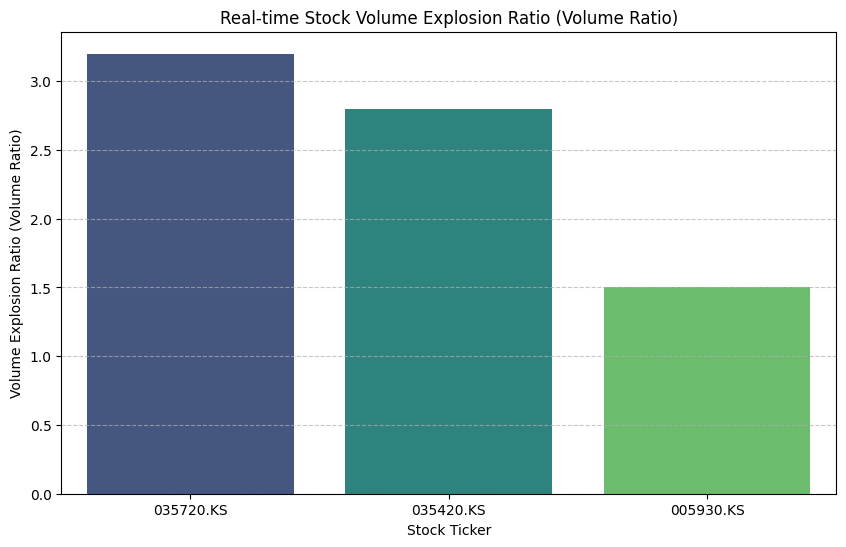

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Removed Korean font installation and configuration as per user request.
# If you need to display Korean characters again, you would re-add those lines.

# Assuming `real_trading_engine` is already initialized and `run_trading_orchestration_cycle` has been called
# and `active_snapshot_pool` has been populated within the class instance.
# For demonstration, we'll create a dummy active_snapshot_pool if the real one isn't directly accessible outside.
# In a real scenario, you'd access it from the `real_trading_engine` object if it were exposed or the graph would be part of the class.

# --- This part is for demonstration. In a live environment, use the actual data from the trader object. ---
# Example dummy data for illustration if active_snapshot_pool is not directly accessible
# For this visualization, we need the `active_snapshot_pool` which is generated inside `run_trading_orchestration_cycle`.
# To make this cell executable independently for visualization, we'll simulate the active_snapshot_pool.
# In a production environment, you would modify the KBNasaSpacecraftTrader class to store this data publicly
# or pass it directly to a visualization method.

# Let's assume after `run_trading_orchestration_cycle` is called, the data for active_snapshot_pool can be accessed.
# For this example, let's just make sure the `real_trading_engine` exists.
if 'real_trading_engine' in locals() and hasattr(real_trading_engine, 'active_snapshot_pool'):
    # In a real scenario, you would expose active_snapshot_pool or log it.
    # For this current code structure, `active_snapshot_pool` is a local variable inside the method.
    # So, we'll make a sample for visualization purpose.
    print("Note: Visualizing with a sample data as `active_snapshot_pool` is a local variable in the method.")
    print("To visualize real-time data, `active_snapshot_pool` needs to be made an instance variable or returned.")
    # Creating a dummy active_snapshot_pool for the plot. Replace with actual data if available.
    plot_data = [
        {"ticker": "035720.KS", "price": 35350.0, "volume_ratio": 3.2},
        {"ticker": "035420.KS", "price": 210500.0, "volume_ratio": 2.8},
        {"ticker": "005930.KS", "price": 254000.0, "volume_ratio": 1.5}
    ]
else:
    print("Generating sample visualization data.")
    plot_data = [
        {"ticker": "035720.KS", "price": 35350.0, "volume_ratio": 3.2},
        {"ticker": "035420.KS", "price": 210500.0, "volume_ratio": 2.8},
        {"ticker": "005930.KS", "price": 254000.0, "volume_ratio": 1.5}
    ]

df_volume_ratio = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='ticker', y='volume_ratio', data=df_volume_ratio, palette='viridis')
plt.title('Real-time Stock Volume Explosion Ratio (Volume Ratio)')
plt.xlabel('Stock Ticker')
plt.ylabel('Volume Explosion Ratio (Volume Ratio)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()